# 3.4 Python Capstone Assignment

### Chlorophyll-a Variation in the Benguela Current

The objective of this assignment is to apply Python geospatial analysis techniques to visualize ESA-CCI ocean colour climatology data and GMRT bathymetry. Using this data, we explored how chlorophyll-a varies spatially and seasonally in relation to coastal ocean topography within the lower Benguela Current region of South Africa.

In [201]:
# Load Modules
import numpy as np
import pandas as pd
import xarray as xr  
import netCDF4 
import matplotlib.pyplot as plt
import matplotlib.colors as colors  
import cartopy.crs as ccrs         
import cartopy.feature as cfeature  
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [202]:
# Install necessary module
!pip install rasterio
import rasterio

In [203]:
# Hide warnings to prevent pop-ups of unnecessary RuntimeWarning
import warnings
warnings.filterwarnings("ignore",category=RuntimeWarning)

### 1. Loading the map of the region bathymetry, using the "terrain" colormap.

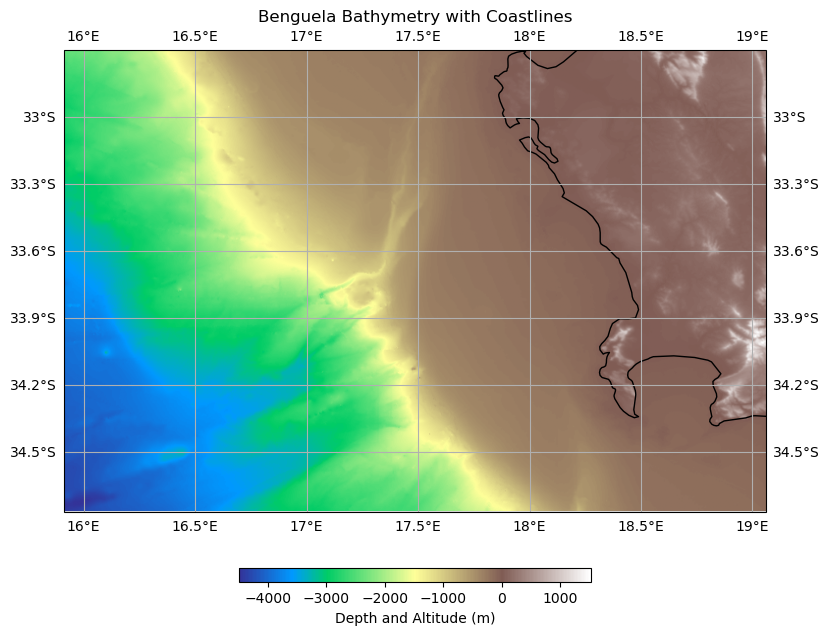

In [204]:
# Define study region (Benguela)
lon_min, lon_max = 15.9104, 19.0613
lat_min, lat_max = -34.7723, -32.7

# Open bathymetry file and crop directly
with rasterio.open("benguela_bathymetry.grd") as src:
    # Define window in geographic coordinates
    window = rasterio.windows.from_bounds(lon_min, lat_min, lon_max, lat_max, src.transform)
    bathy_region = src.read(1, window=window)
    bounds = rasterio.windows.bounds(window, src.transform)

# Extract cropped extent
lon_min_crop, lat_min_crop, lon_max_crop, lat_max_crop = bounds

# Create figure with map projection
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set map extent explicitly
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

# Plot bathymetry with cropped extent
im = ax.imshow(
    bathy_region,
    cmap="terrain",
    extent=[lon_min_crop, lon_max_crop, lat_min_crop, lat_max_crop],
    origin="upper",   # switch to "lower" if flipped
    transform=ccrs.PlateCarree())

# Land fill
ax.add_feature(cfeature.LAND,
               facecolor='none',
               edgecolor='black')

# Add coastlines and gridlines
ax.coastlines(resolution="10m", linewidth=1)
ax.gridlines(draw_labels=True)

# Add colorbar neatly below the map
cbar_ax = inset_axes(ax,
                     width="50%", height="3%",
                     loc="lower center",
                     bbox_to_anchor=(0, -0.15, 1, 1),
                     bbox_transform=ax.transAxes,
                     borderpad=0)
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Depth and Altitude (m)")

# Title
ax.set_title("Benguela Bathymetry with Coastlines")

# Save and display figure
plt.savefig("Figure1_Bathymetry.png", dpi=300)
plt.show()

### 2. Loading a map of the mean annual chlorophyll in the lower Benguela region, using the "viridis" colormap.

In [205]:
# Open dataset
ds = xr.open_dataset(
    "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Subset Benguela region
subset = ds.sel(
    lon=slice(15.9104, 19.0613),
    lat=slice(-32.4412, -34.7723))

# Extract chlorophyll variable
chl = subset['chlor_a']

# Remove invalid values
chl = chl.where(chl > 0)

# Compute annual mean
chl_mean = chl.mean(dim="time")

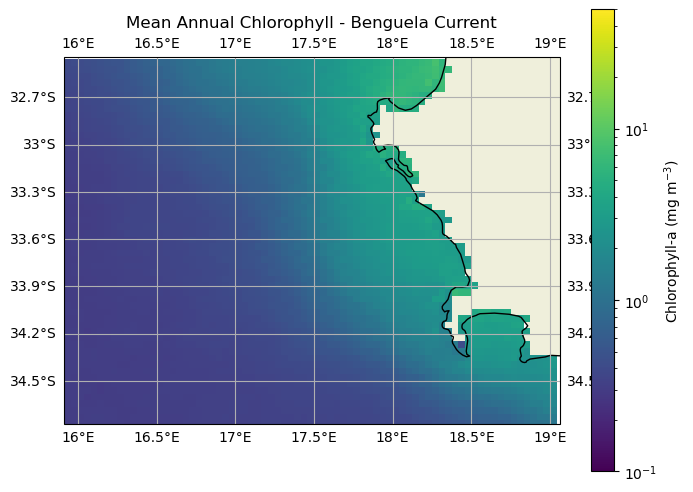

In [206]:
# Create a new figure
fig = plt.figure(figsize=(8,6))

# Create map axes 
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot chlorophyll data on the map
chl_mean.plot(
    
    # Tell cartopy the data are in geographic coordinates
    transform=ccrs.PlateCarree(),
    
    # Colormap
    cmap='viridis',
    
    # Logarithmic scaling for chlorophyll
    norm=colors.LogNorm(vmin=0.1, vmax=50),
    
    # Add colorbar label
    cbar_kwargs={'label': 'Chlorophyll-a (mg m$^{-3}$)'})

# Add coastlines and gridlines
ax.coastlines(resolution='10m')
ax.gridlines(draw_labels = True)

# Add land shading
ax.add_feature(cfeature.LAND)

# Add country borders
ax.add_feature(cfeature.BORDERS)

# Set map extent to Benguela region
ax.set_extent([15.9104, 19.0613, -34.7723, -32.4412])

# Add plot title
plt.title("Mean Annual Chlorophyll - Benguela Current")

# Save figure
plt.savefig("Figure2_Chlorophyll.png", dpi=300, bbox_inches='tight')

# Display the figure
plt.show()

### 3. Loading a faceted figure of the monthly average chlorophyll-a, showing 12 maps, one for each month. We chose the "turbo" colormap in order to contrast the upwelling areas well from the open ocean.

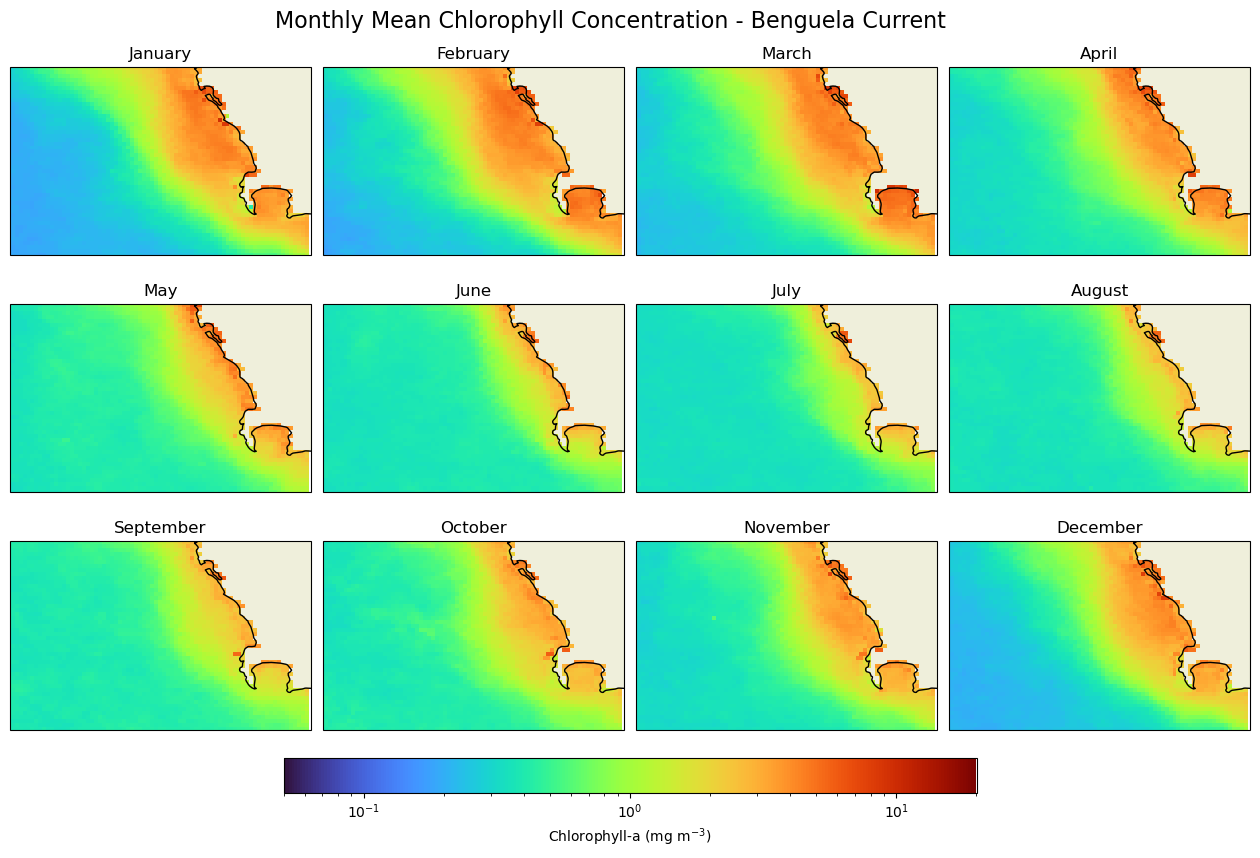

In [207]:
# Open the chlorophyll dataset
ds = xr.open_dataset(
    "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Subset to the Benguela Current region - latitude order is reversed because many oceanographic datasets store latitude from north to south
subset = ds.sel(
    lon=slice(15.9104, 19.0613),
    lat=slice(-32.4412, -34.7723))

# Extract chlorophyll variable
chl = subset['chlor_a']

# Remove invalid values
chl = chl.where(chl > 0)

# Group data by month and compute monthly mean
monthly_mean = chl.groupby("time.month").mean()

# Create a figure with 12 subplots (3 rows x 4 columns)
fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(16, 9),
    subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes array so we can loop through easily
axes = axes.flatten()

# Define month names for titles
month_names = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"]

# Loop through all 12 months
for i in range(12):
    
    # Select the current subplot axis
    ax = axes[i]
    
    # Select chlorophyll data for current month
    data = monthly_mean.sel(month=i+1)
    
    # Plot the monthly chlorophyll map
    im = data.plot(
        
        # Plot on current axis
        ax=ax,
        
        # Coordinate reference system
        transform=ccrs.PlateCarree(),
        
        # Colormap
        cmap='turbo',
        
        # Log scale improves visibility of ocean productivity patterns
        norm=colors.LogNorm(vmin=0.05, vmax=20),
        
        # Turn off automatic colorbar creation
        add_colorbar=False)
    
    # Add coastline
    ax.coastlines(resolution='10m')
    
    # Add land feature
    ax.add_feature(cfeature.LAND)
    
    # Set geographic extent
    ax.set_extent([15.9104, 19.0613, -34.7723, -32.8])
    
    # Add subplot title
    ax.set_title(month_names[i])

# Create one shared colorbar below all subplots
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='horizontal',
    fraction=0.05,
    pad=0.05)
cbar.set_label("Chlorophyll-a (mg m$^{-3}$)")

# Adjust spacing manually
fig.subplots_adjust(
    top=1.0,      # space for title
    bottom=0.18,   # space for colorbar
    hspace=-0.1,   # vertical spacing between rows
    wspace=0.04)    # horizontal spacing between columns)

# Add overall figure title
fig.suptitle(
    "Monthly Mean Chlorophyll Concentration - Benguela Current",
    fontsize=16)

# Save image
plt.savefig("Figure3_Overlay.png", dpi=300, bbox_inches='tight')

# Display figure
plt.show()

### 4. Loading a timeseries plot showing two lines: the mean seasonal cycle of the whole region compared with the timeseries from Namaqualand upwelling zone.

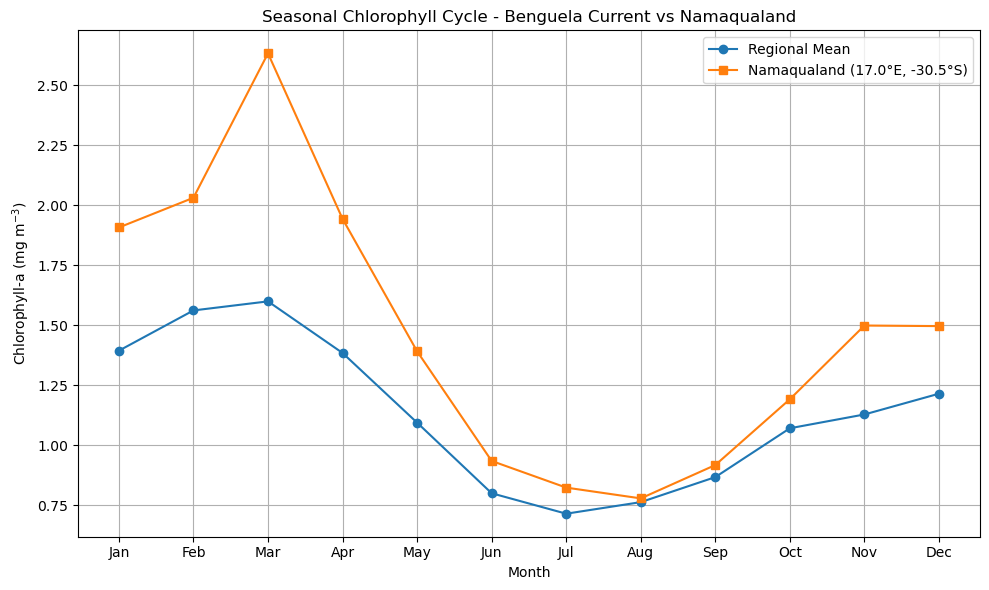

In [208]:
# Open the chlorophyll dataset
ds = xr.open_dataset(
    "ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Subset to Benguela Current region
subset = ds.sel(
    lon=slice(15.9104, 19.0613),
    lat=slice(-32.4412, -34.7723))

# Extract chlorophyll variable
chl = subset['chlor_a']

# Remove invalid values
chl = chl.where(chl > 0)

# 1. Calculate regional mean seasonal cycle

# Compute spatial mean across all latitude and longitude points
regional_mean = chl.mean(dim=['lat', 'lon'])

# 2. Select a single high-chlorophyll grid point

# Comparison point: Namaqualand upwelling zone (strong seasonal bloom)
point_lat = -30.5
point_lon = 17.0

# Extract nearest grid cell to chosen coordinates
point_series = chl.sel(
    lat=point_lat,
    lon=point_lon,
    method='nearest')

# 3. Create month labels
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"]

# Create x-axis values (1–12)
months = np.arange(1, 13)

# 4. Create timeseries plot

# Create figure
plt.figure(figsize=(10,6))

# Plot regional mean seasonal cycle
plt.plot(
    months,
    regional_mean,
    marker='o',
    label='Regional Mean')

# Plot Namaqualand upwelling cell seasonal cycle
plt.plot(
    months,
    point_series,
    marker='s',
    label=f'Namaqualand ({point_lon}°E, {point_lat}°S)')

# 5. Customize plot

# Set x-axis labels
plt.xticks(months, month_names)

# Axis labels
plt.xlabel("Month")
plt.ylabel("Chlorophyll-a (mg m$^{-3}$)")

# Add title
plt.title("Seasonal Chlorophyll Cycle - Benguela Current vs Namaqualand")

# Add grid lines
plt.grid(True)

# Add legend
plt.legend()

# Improve spacing
plt.tight_layout()

# Save image
plt.savefig("Figure7_Seasonal_Cycle.png", dpi=300, bbox_inches='tight')

# Display plot
plt.show()